In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp -r "/content/drive/MyDrive/Tubes Deep Learning/dataset" /content/

In [45]:
import os
import pandas as pd
import numpy as np

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    resnet18,
    ResNet18_Weights
)

from sklearn.model_selection import train_test_split

In [101]:
DATASET_DIR = "/content/dataset"

IMAGE_DIR = f"{DATASET_DIR}/images"
LABEL_FILE = f"{DATASET_DIR}/labels.csv"

In [102]:
df = pd.read_csv(LABEL_FILE)

print(df.shape)

df.head()

(1440, 6)


,filename,fl,fr,rl,rr,hood
0,img_00000.png,0,0,0,0,0
1,img_00001.png,0,0,0,0,0
2,img_00002.png,0,0,0,0,0
3,img_00003.png,0,0,0,0,0
4,img_00004.png,0,0,0,0,0


In [103]:
print(df.shape)
print(df.head())

print(df[['fl','fr','rl','rr','hood']].sum())

(1440, 6)
        filename  fl  fr  rl  rr  hood
0  img_00000.png   0   0   0   0     0
1  img_00001.png   0   0   0   0     0
2  img_00002.png   0   0   0   0     0
3  img_00003.png   0   0   0   0     0
4  img_00004.png   0   0   0   0     0
fl      720
fr      720
rl      720
rr      720
hood    720
dtype: int64


In [104]:
df["state"] = (
    df["fl"].astype(str)
    + df["fr"].astype(str)
    + df["rl"].astype(str)
    + df["rr"].astype(str)
    + df["hood"].astype(str)
)

print("Jumlah state unik:", df["state"].nunique())
print(df["state"].value_counts())

Jumlah state unik: 32
state
00000    45
00001    45
00010    45
00011    45
00100    45
00101    45
00110    45
00111    45
01000    45
01001    45
01010    45
01011    45
01100    45
01101    45
01110    45
01111    45
10000    45
10001    45
10010    45
10011    45
10100    45
10101    45
10110    45
10111    45
11000    45
11001    45
11010    45
11011    45
11100    45
11101    45
11110    45
11111    45
Name: count, dtype: int64


In [105]:
train_parts = []
test_parts = []

for _, group_df in df.groupby("state"):

    group_df = group_df.sort_values("filename")

    # 80% sudut pertama
    train_parts.append(group_df.iloc[:36])

    # 20% sudut terakhir
    test_parts.append(group_df.iloc[36:])

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

In [106]:
weights = ResNet18_Weights.DEFAULT

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [107]:
class CarDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        transform=None
    ):

        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img_path = os.path.join(
            self.image_dir,
            row["filename"]
        )

        image = Image.open(
            img_path
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            [
                row["fl"],
                row["fr"],
                row["rl"],
                row["rr"],
                row["hood"]
            ],
            dtype=torch.float32
        )

        return image, label

In [108]:
train_dataset = CarDataset(
    train_df,
    IMAGE_DIR,
    train_transform
)

test_dataset = CarDataset(
    test_df,
    IMAGE_DIR,
    test_transform
)

In [109]:
print(len(train_dataset))
print(len(test_dataset))

1152
288


In [110]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [111]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [112]:
model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

model.fc = nn.Linear(
    model.fc.in_features,
    5
)

model = model.to(device)

In [113]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [114]:
from tqdm.auto import tqdm

In [117]:
num_epochs = 20

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # TRAINING
    model.train()

    running_loss = 0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{num_epochs} [Train]"
    )

    for images, labels in train_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)

    # VALIDATION
    model.eval()

    running_val_loss = 0

    val_bar = tqdm(
        test_loader,
        desc=f"Epoch {epoch+1}/{num_epochs} [Val]"
    )

    with torch.no_grad():

        for images, labels in val_bar:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += loss.item()

            val_bar.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    val_loss = running_val_loss / len(test_loader)

    val_losses.append(val_loss)

    print(
        f"\nEpoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}\n"
    )

Epoch 1/20 [Train]:   0%|          | 0/36 [00:00<?, ?it/s]

Epoch 1/20 [Val]:   0%|          | 0/9 [00:00<?, ?it/s]


Epoch [1/20] Train Loss: 0.0901 Val Loss: 0.1782



Epoch 2/20 [Train]:   0%|          | 0/36 [00:00<?, ?it/s]

Epoch 2/20 [Val]:   0%|          | 0/9 [00:00<?, ?it/s]

...

Epoch 19/20 [Val]:   0%|          | 0/9 [00:00<?, ?it/s]


Epoch [19/20] Train Loss: 0.0147 Val Loss: 0.2138



Epoch 20/20 [Train]:   0%|          | 0/36 [00:00<?, ?it/s]

Epoch 20/20 [Val]:   0%|          | 0/9 [00:00<?, ?it/s]


Epoch [20/20] Train Loss: 0.0311 Val Loss: 0.2403



In [118]:
from sklearn.metrics import classification_report

In [119]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        preds = (
            probs > 0.5
        ).int()

        all_preds.append(
            preds.cpu()
        )

        all_labels.append(
            labels
        )

In [120]:
all_preds = torch.cat(
    all_preds
).numpy()

all_labels = torch.cat(
    all_labels
).numpy()

In [125]:
from sklearn.metrics import accuracy_score

label_accuracy = accuracy_score(
    all_labels.flatten(),
    all_preds.flatten()
)

print(label_accuracy)

0.9243055555555556


In [121]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[
            "Front Left Door",
            "Front Right Door",
            "Rear Left Door",
            "Rear Right Door",
            "Hood"
        ]
    )
)

                  precision    recall  f1-score   support

 Front Left Door       0.97      0.78      0.87       144
Front Right Door       0.87      0.92      0.89       144
  Rear Left Door       0.97      0.90      0.93       144
 Rear Right Door       0.98      0.87      0.92       144
            Hood       0.98      0.99      0.99       144

       micro avg       0.95      0.89      0.92       720
       macro avg       0.96      0.89      0.92       720
    weighted avg       0.96      0.89      0.92       720
     samples avg       0.90      0.86      0.87       720



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [122]:
print(train_df.head())
print(test_df.head())

        filename  fl  fr  rl  rr  hood  state
0  img_00000.png   0   0   0   0     0  00000
1  img_00001.png   0   0   0   0     0  00000
2  img_00002.png   0   0   0   0     0  00000
3  img_00003.png   0   0   0   0     0  00000
4  img_00004.png   0   0   0   0     0  00000
        filename  fl  fr  rl  rr  hood  state
0  img_00036.png   0   0   0   0     0  00000
1  img_00037.png   0   0   0   0     0  00000
2  img_00038.png   0   0   0   0     0  00000
3  img_00039.png   0   0   0   0     0  00000
4  img_01280.png   0   0   0   0     0  00000


In [126]:
best_val_loss = float("inf")

In [127]:
val_loss = running_val_loss / len(test_loader)

val_losses.append(val_loss)

# Save best model
if val_loss < best_val_loss:

    best_val_loss = val_loss

    torch.save(
        model.state_dict(),
        "best_resnet18.pth"
    )

    print(
        f"✓ Best model saved "
        f"(Val Loss: {val_loss:.4f})"
    )

print(
    f"\nEpoch [{epoch+1}/{num_epochs}] "
    f"Train Loss: {train_loss:.4f} "
    f"Val Loss: {val_loss:.4f}\n"
)

✓ Best model saved (Val Loss: 0.2403)

Epoch [20/20] Train Loss: 0.0311 Val Loss: 0.2403



In [128]:
torch.save(
    model.state_dict(),
    "final_resnet18.pth"
)

In [129]:
from torchvision.models import (
    resnet18,
    ResNet18_Weights
)

model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

model.fc = nn.Linear(
    model.fc.in_features,
    5
)

model.load_state_dict(
    torch.load(
        "best_resnet18.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

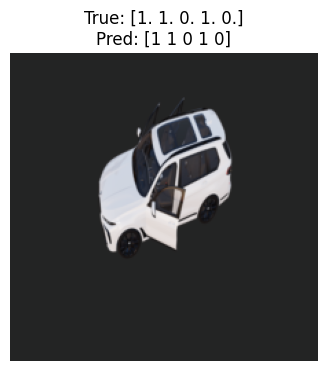

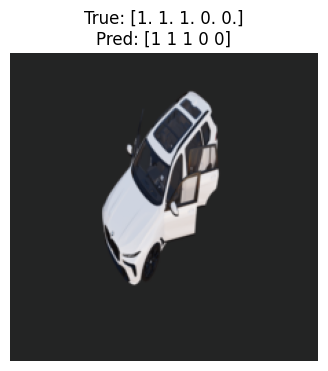

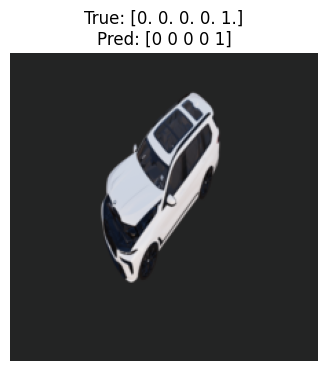

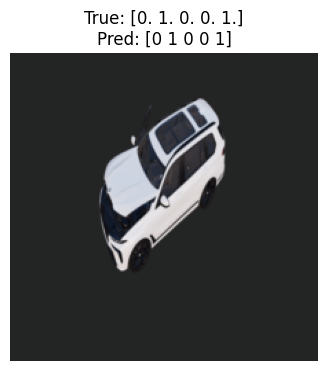

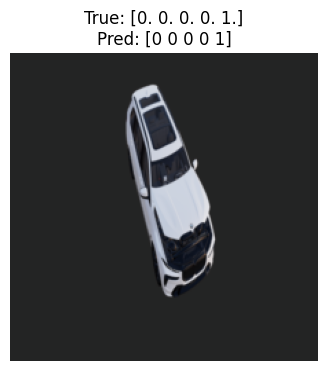

In [133]:
import random

indices = random.sample(
    range(len(test_dataset)),
    5
)

for idx in indices:

    image, label = test_dataset[idx]

    image_input = image.unsqueeze(0).to(device)

    with torch.no_grad():

        output = model(image_input)

        prob = torch.sigmoid(output)

        pred = (prob > 0.5).int()

    img = image.cpu()

    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

    img = img * std + mean

    plt.figure(figsize=(4,4))
    plt.imshow(
        img.permute(1,2,0).clamp(0,1)
    )

    plt.title(
        f"True: {label.numpy()}\n"
        f"Pred: {pred.cpu().numpy()[0]}"
    )

    plt.axis("off")
    plt.show()

In [131]:
model.eval()

wrong_cases = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).int()

        for i in range(len(labels)):

            if not torch.equal(
                preds[i].cpu(),
                labels[i].int()
            ):

                wrong_cases.append(
                    (
                        images[i].cpu(),
                        labels[i],
                        preds[i].cpu()
                    )
                )

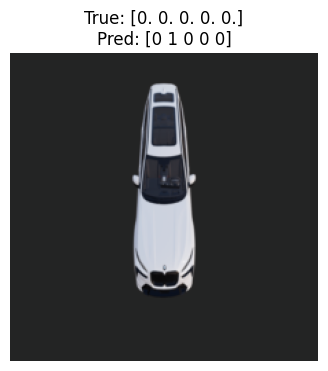

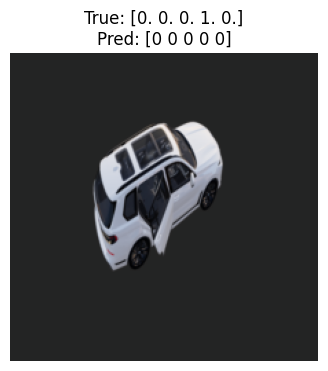

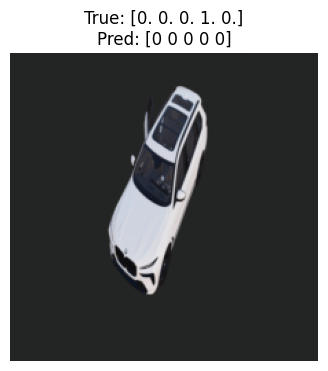

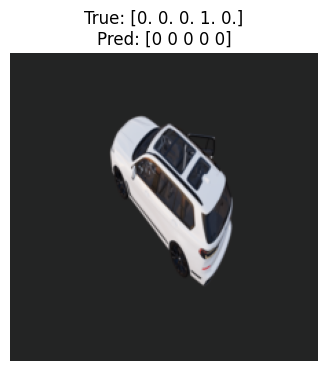

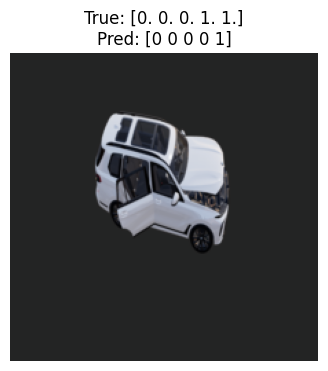

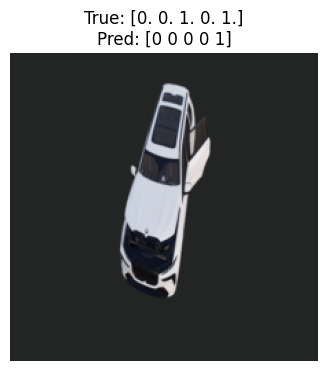

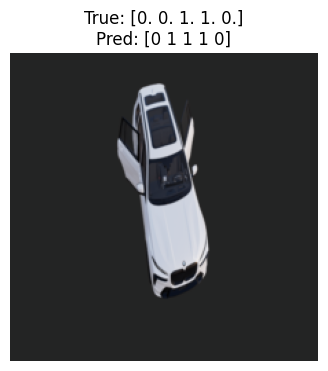

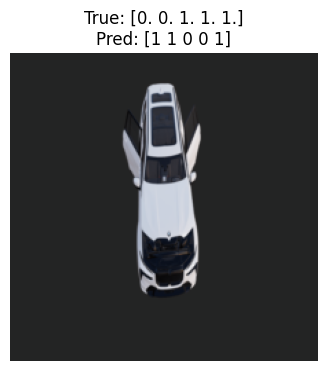

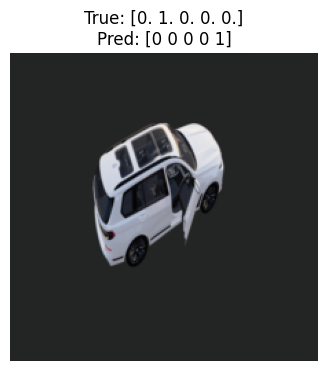

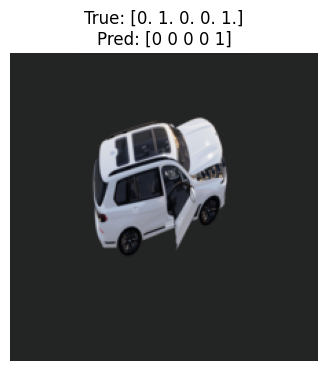

In [132]:
for img, true_label, pred_label in wrong_cases[:10]:

    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

    img = img * std + mean

    plt.figure(figsize=(4,4))
    plt.imshow(img.permute(1,2,0).clamp(0,1))

    plt.title(
        f"True: {true_label.numpy()}\n"
        f"Pred: {pred_label.numpy()}"
    )

    plt.axis("off")
    plt.show()